# FNN: ACASXU Workshop Tutorial

This notebook shows how to load an ACASXU benchmark network in StarV, build the corresponding input Star set, and read the VNNLIB property used for verification.


## 1. Setup

Import the StarV utilities used in the workshop and resolve paths relative to the local StarV package. This keeps the notebook working even when Jupyter is launched from a different folder.


In [ ]:
# Numerical arrays are used for bounds and parsed VNNLIB data.
import numpy as np
import StarV

# Star is the symbolic set representation used by StarV reachability routines.
from StarV.set.star import Star

# load_ACASXU loads the curated ACASXU benchmark from StarV MAT files.
# load_neural_network demonstrates loading a network file such as ONNX.
from StarV.util.load import load_ACASXU, load_neural_network

# VNNLIB helpers read benchmark input boxes and output safety constraints.
from StarV.util.vnnlib import read_vnnlib_simple, get_num_inputs_outputs
from StarV.util.lp_solver import sample

# Verification helpers run approximate and exact breadth-first reachability.
from StarV.verifier.verifier import qualiVerifyExactBFS, qualiVerifyApproxBFS

from pathlib import Path
import matplotlib.pyplot as plt

# repo_root points at the repository root that contains the StarV package folder.
repo_root = Path(StarV.__file__).resolve().parents[1]


def as_list(reach_set):
    """Normalize a Star or list of Stars for plotting/counting."""
    return reach_set if isinstance(reach_set, list) else [reach_set]

## 2. ACAS Xu Network And Advisories

ACAS Xu is an aircraft collision-avoidance advisory system for unmanned aircraft. The neural-network benchmark compresses a large lookup-table policy into a family of feedforward ReLU networks. Each network maps a relative aircraft encounter state to advisory scores for possible horizontal maneuvers.

The VNN-COMP ACAS Xu benchmark represents the networks in ONNX and the safety properties in VNN-LIB. This is why the tutorial shows both the StarV built-in loader and the ONNX/VNN-LIB path used by benchmark verification tools.

Each network takes five continuous aircraft-encounter variables:

`x = (rho, theta, psi, v_own, v_int)`

| Symbol | Meaning | Units |
| --- | --- | --- |
| `rho` | Distance from ownship to intruder | feet |
| `theta` | Angle to intruder relative to ownship heading | radians |
| `psi` | Intruder heading angle relative to ownship heading | radians |
| `v_own` | Ownship speed | ft/s |
| `v_int` | Intruder speed | ft/s |

The network returns five advisory scores:

`y = (y_COC, y_WL, y_WR, y_SL, y_SR)`

| Output | Meaning |
| --- | --- |
| `COC` | Clear-of-Conflict |
| `WL` | Weak Left |
| `WR` | Weak Right |
| `SL` | Strong Left |
| `SR` | Strong Right |

## 3. Load The Built-In ACASXU Benchmark

For most StarV ACASXU examples, load_ACASXU is the simplest path. It returns the network, normalized input bounds, and the unsafe output region for the selected property.


In [2]:
# ACASXU networks are indexed by (x, y). This workshop uses network 1_1.
net_id = (1, 1)

# spec_id selects the ACASXU safety property. Property 1 constrains the COC score.
spec_id = 1

# The loader returns both the network and the verification property data.
net, lb, ub, unsafe_mat, unsafe_vec = load_ACASXU(*net_id, spec_id)
print('Information about the loaded ACASXU network and property:')
print(net)

# lb and ub are already normalized using the ACASXU scaling constants.
print(f"Input Specification for ACASXU property {spec_id}:")
print(f"lb: {lb}")
print(f"ub: {ub}")

# A Star set compactly represents all inputs in the box [lb, ub].
print("Constructing a Star set from the input bounds...")
S = Star(lb, ub)

print(f"Star: {S}")
repr(S)

print(f"Unsafe output constraints (unsafe_mat, unsafe_vec):")
print(f"{unsafe_mat} <= {unsafe_vec}")

Information about the loaded ACASXU network and property:

=============NETWORK===============
Network type: ffnn_ACASXU_1_1
Input Dimension: 5
Output Dimension: 5
Number of Layers: 13
Layer types:
Layer 0: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 5, dtype=float64)
Layer 1: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 2: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 3: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 4: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 5: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 6: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 7: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 8: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 9: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 10: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (

## 4. Load The ONNX Network And VNNLIB Property

This section mirrors a standard verification benchmark layout: an ONNX network plus a VNNLIB property file. The VNNLIB parser provides the input box and output constraints.


In [3]:
# ACASXU networks are indexed by (x, y). This workshop uses network 1_1.
net_id = (1, 1)

# spec_id selects the ACASXU safety property. Property 1 constrains the COC score.
spec_id = 1

# Path to the ONNX copy of ACASXU 1_1.
network_path = str(repo_root / f"StarV/util/data/nets/ACASXU/onnx/ACASXU_run2a_{net_id[0]}_{net_id[1]}_batch_2000.onnx")
net_type = f"ACASXU_FFNN_{net_id[0]}_{net_id[1]}"

print('Information about the loaded ACASXU network and property:')
# Convert the ONNX network into StarV layers.
net = load_neural_network(network_path, net_type=net_type)
print(net)

# Property 1 is stored in VNNLIB format next to the ONNX benchmark files.
vnnlib_file_dir = str(repo_root / f"StarV/util/data/nets/ACASXU/onnx/prop_{spec_id}.vnnlib")

# The parser needs the ONNX input/output dimensions to interpret the property.
num_inputs, num_outputs, inp_dtype = get_num_inputs_outputs(network_path)
vnnlib_rv = read_vnnlib_simple(vnnlib_file_dir, num_inputs, num_outputs)

# Each VNNLIB entry is an input box plus a list of output constraints.
box, spec_list = vnnlib_rv[0]
bounds = np.array(box, dtype=inp_dtype)
unsafe_mat, unsafe_vec = spec_list[0]

# Convert the parsed input box into lower and upper bound vectors.
lb, ub = bounds[:, 0], bounds[:, 1]
print(f"Input Specification for ACASXU property {spec_id}:")
print(f"lb: {lb}")
print(f"ub: {ub}")

# Build the corresponding Star input set for reachability.
print("Constructing a Star set from the input bounds...")
input_set = Star(lb, ub)

print(f"Star: {input_set}")
repr(input_set)

print(f"Unsafe output constraints (unsafe_mat, unsafe_vec):")
print(f"{unsafe_mat} <= {unsafe_vec}")

Information about the loaded ACASXU network and property:

=============NETWORK===============
Network type: ACASXU_FFNN_1_1
Input Dimension: 5
Output Dimension: 5
Number of Layers: 13
Layer types:
Layer 0: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 5, dtype=float64)
Layer 1: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 2: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 3: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 4: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 5: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 6: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 7: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 8: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (50, 50, dtype=float64)
Layer 9: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 10: <class 'StarV.layer.FullyConnectedLayer.FullyConnectedLayer'> (

## 5. Run Reachability-Based Verification

The next cells compare two StarV verification modes. Approximate BFS over-approximates the reachable output set and is usually faster. Exact BFS splits ReLU cases more precisely, which can produce many more intermediate Stars.

Both calls check whether the reachable output set intersects the unsafe output constraints parsed from VNN-LIB.

For safety verification, the input set $X$ is a physical operating region. In ACAS Xu, this region describes a family of aircraft encounter states, such as ranges of relative distance, headings, and velocities.

A linear input operating region can be written as

$$
X_{safe} = \{x : A_{in}x \leq b_{in}\}.
$$

StarV represents this region with a Star set and propagates it through the neural network. Given an unsafe output region $U$, safety is proved when the reachable outputs do not intersect the unsafe region:

$$
f(X_{safe}) \cap U = \emptyset.
$$

In the cells below, `input_set` is the Star representation of $X_{safe}$, and `unsafe_mat, unsafe_vec` define the unsafe output region $U$.

### Approximate BFS

Approximate verification propagates one over-approximated Star through the network. If the final over-approximation intersects the unsafe region, the result is `UNKNOWN`; otherwise the property is proved safe for the input set.

LP solver options: 'gurobi', 'glpk', 'linprog', 'estimate'

In [4]:
lp_solver = 'gurobi'
output_set, unsafe_output_set, safety_verification_result = qualiVerifyApproxBFS(
    net, input_set, unsafe_mat, unsafe_vec, lp_solver=lp_solver
)

Computing layer 0 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 1 ReLULayer reachable set...
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-10
Number of stars: 1
Computing layer 2 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 3 ReLULayer reachable set...
Number of stars: 1
Computing layer 4 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 5 ReLULayer reachable set...
Number of stars: 1
Computing layer 6 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 7 ReLULayer reachable set...
Number of stars: 1
Computing layer 8 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 9 ReLULayer reachable set...
Number of stars: 1
Computing layer 10 FullyConnectedLayer reachable set...
Number of stars: 1
Computing layer 11 ReLULayer reachable set...
Number of stars: 1
Computing layer 12 FullyConnectedLayer reachable set...
Number of stars: 1


In [5]:
print('Approximate Reachability Verification result:')
print(f"Output set: generated {len(as_list(output_set))} output Star(s)")
print(f"Unsafe output set: generated {len(as_list(unsafe_output_set))} output Star(s)")
print(f"Safety verification result: {safety_verification_result}")

Approximate Reachability Verification result:
Output set: generated 1 output Star(s)
Unsafe output set: generated 1 output Star(s)
Safety verification result: UNKNOWN


### Output Range Plot

This figure projects the reachable output Star onto each advisory score. The shaded constraint row shows the safe side, the unsafe side, the VNN-LIB unsafe boundary, and any reachable range that overlaps the unsafe region.

Reachable output ranges (lower bounds, upper bounds):
[ -57.15662  -90.553    -65.22168 -155.72311 -107.74281]
[172.83759 220.42764 225.78886 240.63825 240.71189]
Unsafe output ranges (lower bounds, upper bounds):
[   3.99113  -66.88498  -47.64843 -151.48113 -104.40583]
[172.83759 220.42764 225.78886 240.63825 240.71189]


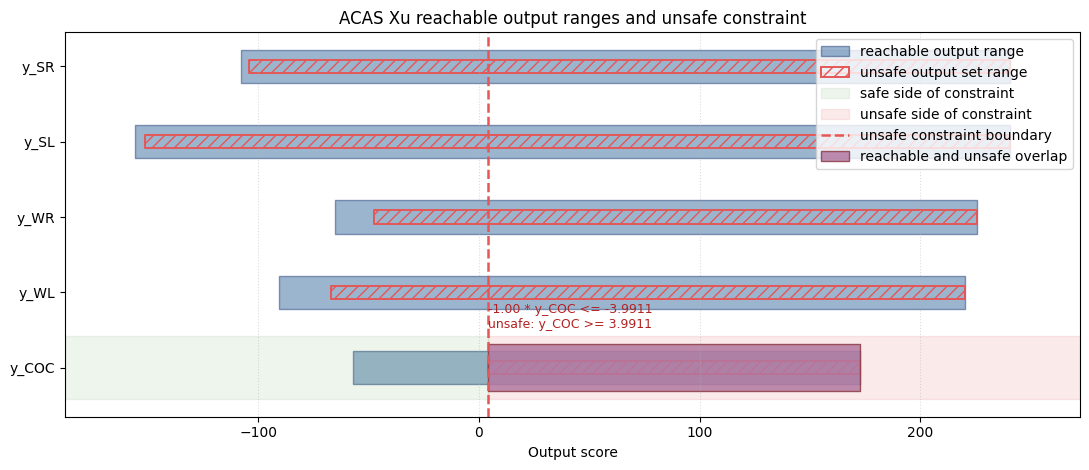

In [6]:
output_labels = ['COC', 'WL', 'WR', 'SL', 'SR']


def combined_star_ranges(star_or_stars, lp_solver='estimate'):
    """Return one lower/upper range vector for a Star or a list of Stars."""
    stars = [star for star in as_list(star_or_stars) if hasattr(star, 'getRanges')]
    if not stars:
        return None, None

    lower_bounds, upper_bounds = [], []
    for star in stars:
        try:
            lb_i, ub_i = star.getRanges(lp_solver=lp_solver)
        except Exception:
            lb_i, ub_i = star.getRanges(lp_solver='estimate')
        lower_bounds.append(np.asarray(lb_i, dtype=float))
        upper_bounds.append(np.asarray(ub_i, dtype=float))

    return np.min(lower_bounds, axis=0), np.max(upper_bounds, axis=0)


reachable_lb, reachable_ub = combined_star_ranges(output_set, lp_solver=lp_solver)
unsafe_lb, unsafe_ub = combined_star_ranges(unsafe_output_set, lp_solver=lp_solver)

print("Reachable output ranges (lower bounds, upper bounds):")
print(reachable_lb)
print(reachable_ub)
print('Unsafe output ranges (lower bounds, upper bounds):')
print(unsafe_lb)
print(unsafe_ub)

axis_constraints = []
for row, rhs in zip(np.atleast_2d(unsafe_mat), np.ravel(unsafe_vec)):
    row = np.asarray(row, dtype=float)
    nonzero = np.flatnonzero(np.abs(row) > 1e-10)
    if len(nonzero) == 1:
        output_index = int(nonzero[0])
        coef = row[output_index]
        boundary = float(rhs / coef)
        unsafe_direction = '<=' if coef > 0 else '>='
        axis_constraints.append((output_index, coef, float(rhs), boundary, unsafe_direction))

if reachable_lb is None:
    raise ValueError('Run the approximate verification cell before plotting output ranges.')

constraint_boundaries = [boundary for _, _, _, boundary, _ in axis_constraints]
plot_min = min(np.min(reachable_lb), *(constraint_boundaries or [np.min(reachable_lb)]))
plot_max = max(np.max(reachable_ub), *(constraint_boundaries or [np.max(reachable_ub)]))
plot_pad = 0.08 * max(plot_max - plot_min, 1.0)
x_min, x_max = plot_min - plot_pad, plot_max + plot_pad

fig, ax = plt.subplots(figsize=(11, 4.8))
y_positions = np.arange(len(output_labels))

for i, label in enumerate(output_labels):
    ax.broken_barh(
        [(reachable_lb[i], reachable_ub[i] - reachable_lb[i])],
        (i - 0.22, 0.44),
        facecolors='#4C78A8',
        edgecolors='#2F4B7C',
        alpha=0.55,
        label='reachable output range' if i == 0 else None,
    )

    if unsafe_lb is not None:
        ax.broken_barh(
            [(unsafe_lb[i], unsafe_ub[i] - unsafe_lb[i])],
            (i - 0.09, 0.18),
            facecolors='none',
            edgecolors='#E45756',
            hatch='///',
            linewidth=1.4,
            label='unsafe output set range' if i == 0 else None,
        )

for output_index, coef, rhs, boundary, unsafe_direction in axis_constraints:
    y = y_positions[output_index]
    if unsafe_direction == '>=':
        safe_start, safe_end = x_min, boundary
        unsafe_start, unsafe_end = boundary, x_max
    else:
        safe_start, safe_end = boundary, x_max
        unsafe_start, unsafe_end = x_min, boundary

    ax.fill_betweenx(
        [y - 0.42, y + 0.42],
        safe_start,
        safe_end,
        color='#59A14F',
        alpha=0.10,
        label='safe side of constraint',
    )
    ax.fill_betweenx(
        [y - 0.42, y + 0.42],
        unsafe_start,
        unsafe_end,
        color='#E45756',
        alpha=0.12,
        label='unsafe side of constraint',
    )
    ax.axvline(
        boundary,
        color='#E45756',
        linestyle='--',
        linewidth=1.8,
        label='unsafe constraint boundary',
    )

    overlap_start = max(reachable_lb[output_index], unsafe_start)
    overlap_end = min(reachable_ub[output_index], unsafe_end)
    if overlap_end >= overlap_start:
        ax.broken_barh(
            [(overlap_start, overlap_end - overlap_start)],
            (y - 0.31, 0.62),
            facecolors='#B279A2',
            edgecolors='#8E3B46',
            alpha=0.85,
            label='reachable and unsafe overlap',
        )

    constraint_text = (
        f'{coef:.2f} * y_{output_labels[output_index]} <= {rhs:.5g}\n'
        f'unsafe: y_{output_labels[output_index]} {unsafe_direction} {boundary:.5g}'
    )
    ax.text(
        boundary,
        y + 0.48,
        constraint_text,
        ha='left',
        va='bottom',
        color='#B22222',
        fontsize=9,
    )

ax.set_xlim(x_min, x_max)
ax.set_yticks(y_positions)
ax.set_yticklabels([f'y_{name}' for name in output_labels])
ax.set_xlabel('Output score')
ax.set_title('ACAS Xu reachable output ranges and unsafe constraint')
ax.grid(axis='x', linestyle=':', alpha=0.45)

handles, labels = ax.get_legend_handles_labels()
unique = {}
for handle, label in zip(handles, labels):
    if label and not label.startswith('_'):
        unique.setdefault(label, handle)
ax.legend(unique.values(), unique.keys(), loc='upper right')
plt.tight_layout()
plt.show()

### Exact BFS

Exact verification tracks ReLU splits exactly. This can refine the safety answer, but it may create many Stars as the network depth increases.

In [7]:
lp_solver = 'gurobi'
input_set_list = as_list(input_set)
output_set, unsafe_output_set, counter_example_sets, safety_verification_result = qualiVerifyExactBFS(
    net, input_set_list, unsafe_mat, unsafe_vec, lp_solver=lp_solver
)

Computing layer 0 FullyConnectedLayer reachable set...
Number of stars/probstars: 1
Computing layer 1 ReLULayer reachable set...
Number of stars/probstars: 149
Computing layer 2 FullyConnectedLayer reachable set...
Number of stars/probstars: 149
Computing layer 3 ReLULayer reachable set...
Number of stars/probstars: 1113
Computing layer 4 FullyConnectedLayer reachable set...
Number of stars/probstars: 1113
Computing layer 5 ReLULayer reachable set...
Number of stars/probstars: 8420
Computing layer 6 FullyConnectedLayer reachable set...
Number of stars/probstars: 8420
Computing layer 7 ReLULayer reachable set...
Number of stars/probstars: 18666
Computing layer 8 FullyConnectedLayer reachable set...
Number of stars/probstars: 18666
Computing layer 9 ReLULayer reachable set...
Number of stars/probstars: 31049
Computing layer 10 FullyConnectedLayer reachable set...
Number of stars/probstars: 31049
Computing layer 11 ReLULayer reachable set...
Number of stars/probstars: 39835
Computing laye

In [8]:
print('Exact Reachability Verification result:')
print(f"Output set: generated {len(output_set)} output Star(s)")
print(f"Safety Verification result: ")
print(f"Number of SAFE / UNSAT queries: {len([r for r in safety_verification_result if r == 'UNSAT'])}")
print(f"Number of UNSAFE / SAT queries: {len([r for r in safety_verification_result if r == 'SAT'])}")
print(f"Unsafe output set: {len(unsafe_output_set)} unsafe Star(s)")
print(f"Number of countereexample sets: {len(counter_example_sets)}")

Exact Reachability Verification result:
Output set: generated 39835 output Star(s)
Safety Verification result: 
Number of SAFE / UNSAT queries: 39835
Number of UNSAFE / SAT queries: 0
Unsafe output set: 0 unsafe Star(s)
Number of countereexample sets: 0
